<a href="https://colab.research.google.com/github/vaishnavipoojary2202/malicious-url-detection/blob/smith-eda/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
df = pd.read_csv(
    "/content/drive/MyDrive/ML mini/dataset/dataset_phishing.csv"
)

In [36]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape:
(11430, 89)

Column Names:
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks',

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percen

In [37]:
print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:


,0
url,0
length_url,0
length_hostname,0
ip,0
nb_dots,0
...,...
web_traffic,0
dns_record,0
google_index,0
page_rank,0



Duplicate Rows:
0


In [38]:
for column in df.columns:
    print(f"\nColumn: {column}")
    print(df[column].value_counts().head(20))


Column: url
url
http://e710z0ear.du.r.appspot.com/c:/users/user/downlo                                                                                                                                                                                         2
http://office365-login-outlook.el.r.appspot.com/wp-content/xp.php                                                                                                                                                                              1
http://graceleadershipfoundation.org/modules/mod_simplefileuploadv1.3/connect/                                                                                                                                                                 1
http://fience.vot.pl/xl                                                                                                                                                                                                                        1
https://usbank.app.

# 1. Exploratory Data Analysis

This section explores the structure, distribution, class balance, and statistical characteristics of the phishing URL dataset.

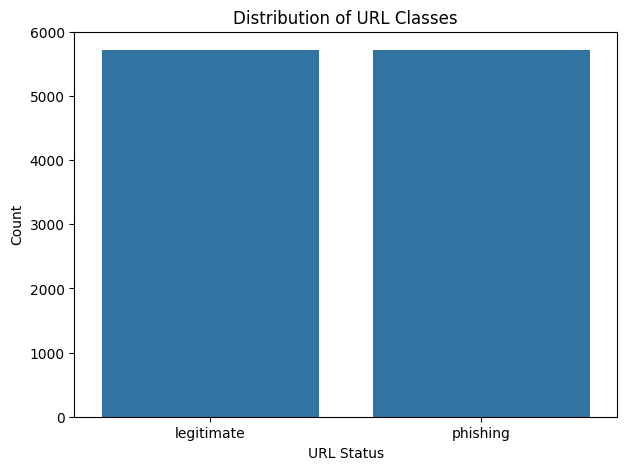

In [39]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='status')

plt.title('Distribution of URL Classes')
plt.xlabel('URL Status')
plt.ylabel('Count')

plt.show()

In [40]:
print(df['status'].value_counts())
print("\nClass proportions:")
print(df['status'].value_counts(normalize=True) * 100)

status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Class proportions:
status
legitimate    50.0
phishing      50.0
Name: proportion, dtype: float64


In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
length_url,11430.0,61.126684,5.529732e+01,12.0,33.00,47.0,71.00,1641.0
length_hostname,11430.0,21.090289,1.077717e+01,4.0,15.00,19.0,24.00,214.0
ip,11430.0,0.150569,3.576436e-01,0.0,0.00,0.0,0.00,1.0
nb_dots,11430.0,2.480752,1.369686e+00,1.0,2.00,2.0,3.00,24.0
nb_hyphens,11430.0,0.997550,2.087087e+00,0.0,0.00,0.0,1.00,43.0
...,...,...,...,...,...,...,...,...
domain_age,11430.0,4062.543745,3.107785e+03,-12.0,972.25,3993.0,7026.75,12874.0
web_traffic,11430.0,856756.643307,1.995606e+06,0.0,0.00,1651.0,373845.50,10767986.0
dns_record,11430.0,0.020122,1.404254e-01,0.0,0.00,0.0,0.00,1.0
google_index,11430.0,0.533946,4.988682e-01,0.0,0.00,1.0,1.00,1.0


In [42]:
constant_features = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))
print("\nConstant features:")
print(constant_features)

Number of constant features: 6

Constant features:
['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']


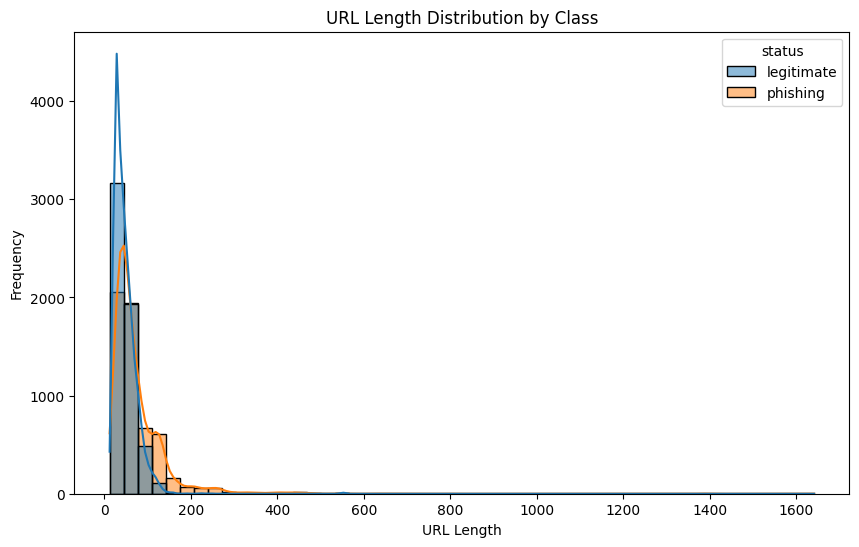

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='length_url',
    hue='status',
    kde=True,
    bins=50
)

plt.title('URL Length Distribution by Class')
plt.xlabel('URL Length')
plt.ylabel('Frequency')

plt.show()

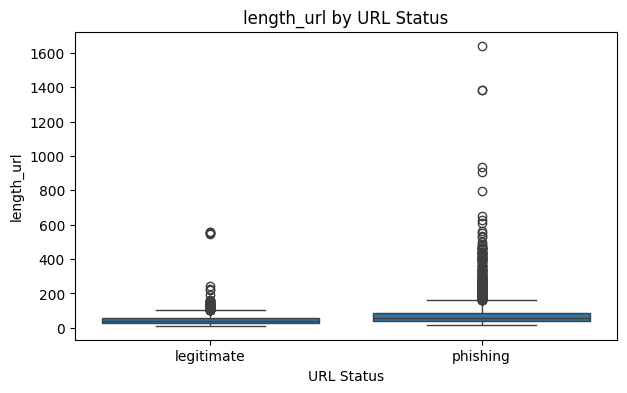

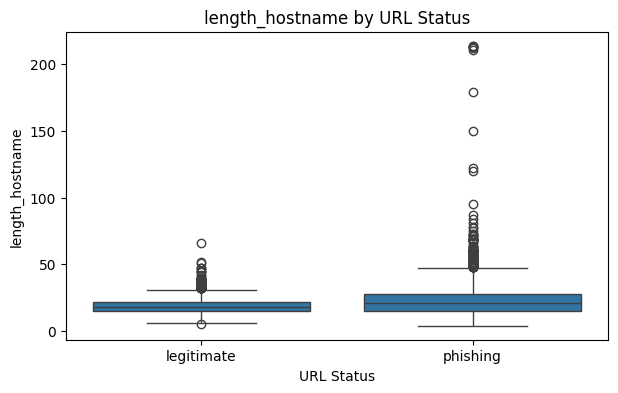

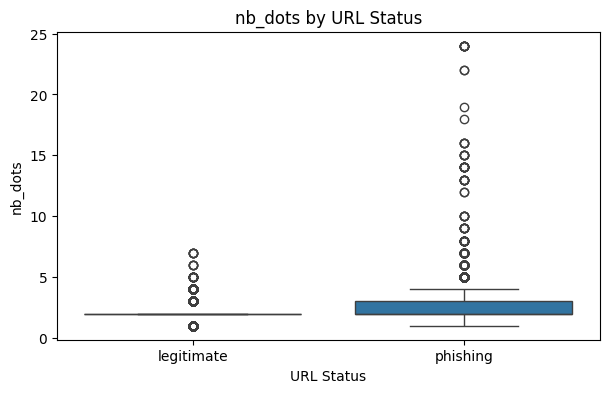

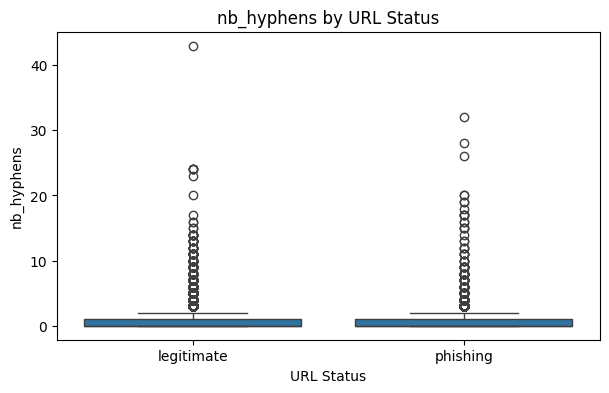

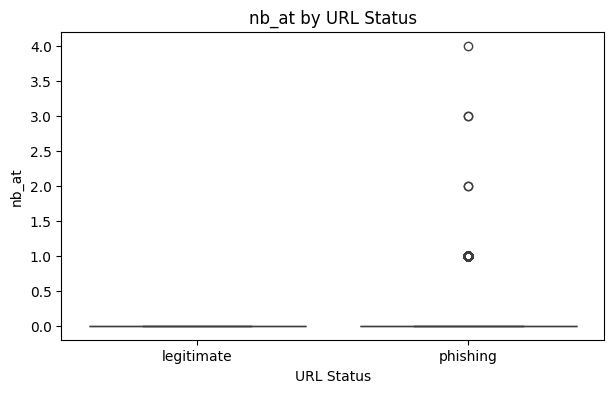

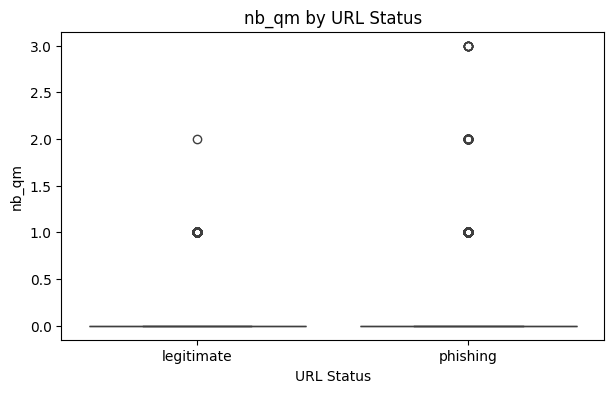

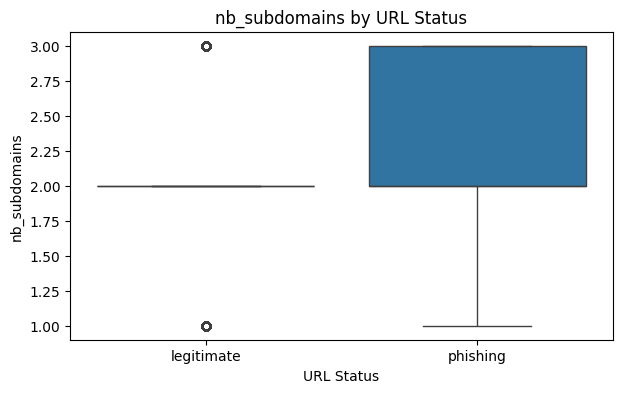

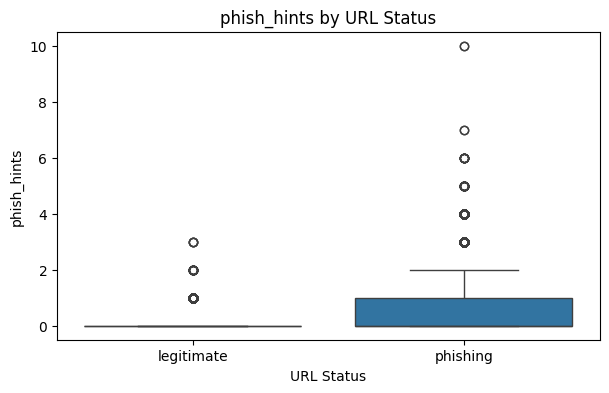

In [44]:
features = [
    'length_url',
    'length_hostname',
    'nb_dots',
    'nb_hyphens',
    'nb_at',
    'nb_qm',
    'nb_subdomains',
    'phish_hints'
]

for feature in features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x='status',
        y=feature
    )

    plt.title(f'{feature} by URL Status')
    plt.xlabel('URL Status')
    plt.ylabel(feature)

    plt.show()

In [45]:
df['status_encoded'] = df['status'].map({
    'legitimate': 0,
    'phishing': 1
})

In [46]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numeric_df.corr()['status_encoded'].sort_values(
    ascending=False
)

display(correlation)

,status_encoded
status_encoded,1.000000
google_index,0.731171
ratio_digits_url,0.356395
domain_in_title,0.342807
phish_hints,0.335393
...,...
ratio_nullHyperlinks,NaN
ratio_intRedirection,NaN
ratio_intErrors,NaN
submit_email,NaN


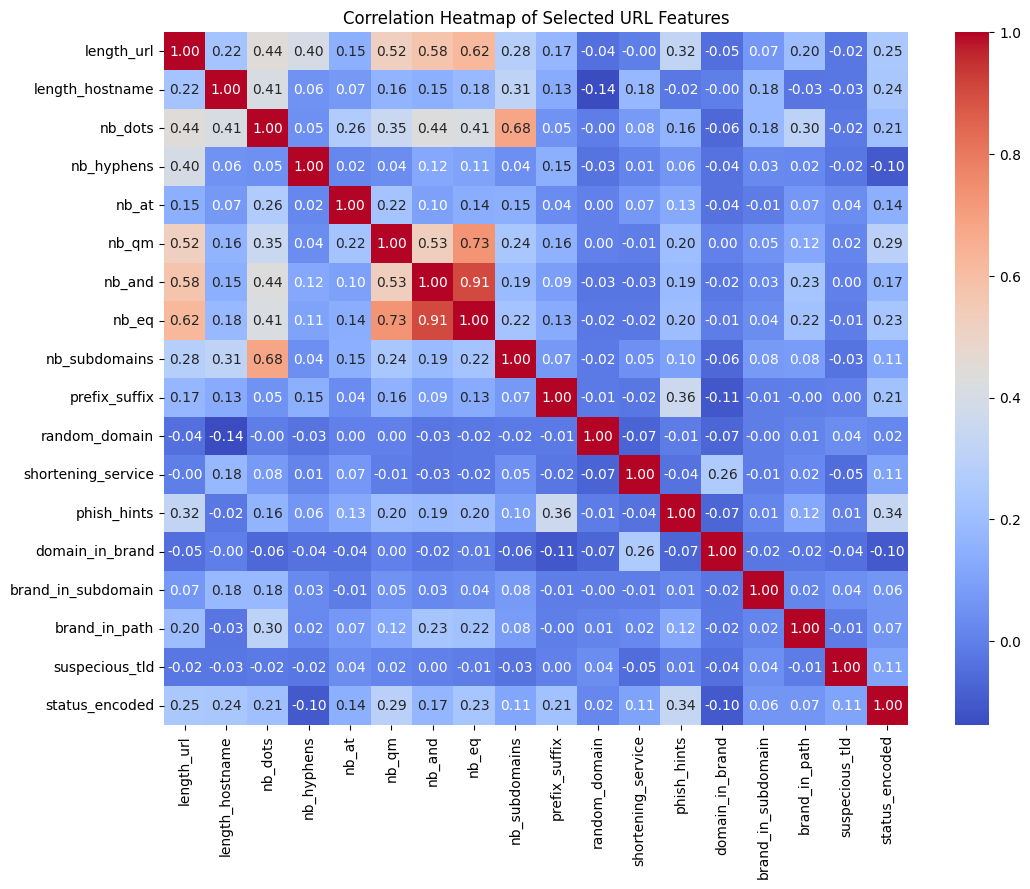

In [47]:
corr_features = [
    'length_url',
    'length_hostname',
    'nb_dots',
    'nb_hyphens',
    'nb_at',
    'nb_qm',
    'nb_and',
    'nb_eq',
    'nb_subdomains',
    'prefix_suffix',
    'random_domain',
    'shortening_service',
    'phish_hints',
    'domain_in_brand',
    'brand_in_subdomain',
    'brand_in_path',
    'suspecious_tld',
    'status_encoded'
]

plt.figure(figsize=(12, 9))

sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Selected URL Features')

plt.show()

In [48]:
selected_features = [
    'length_url',
    'length_hostname',
    'nb_dots',
    'nb_hyphens',
    'nb_at',
    'nb_qm',
    'nb_subdomains',
    'shortening_service',
    'phish_hints',
    'domain_in_brand',
    'brand_in_subdomain',
    'brand_in_path',
    'suspecious_tld'
]

feature_comparison = df.groupby('status')[selected_features].mean().T

display(feature_comparison)

status,legitimate,phishing
length_url,47.381452,74.871916
length_hostname,18.521960,23.658618
nb_dots,2.197200,2.764304
nb_hyphens,1.206474,0.788626
nb_at,0.000000,0.044444
nb_qm,0.033946,0.248469
nb_subdomains,2.159755,2.303587
shortening_service,0.088539,0.158355
phish_hints,0.045144,0.610324
domain_in_brand,0.134208,0.074191


## EDA Summary

The dataset contains 11,430 URL records and 89 columns, including the URL, 87 existing URL-related features, and the target variable `status`.

The dataset is perfectly balanced, containing 5,715 legitimate URLs and 5,715 phishing URLs, representing 50% of each class.

No missing values or duplicate records were identified.

Six constant features were identified:
- `nb_or`
- `ratio_nullHyperlinks`
- `ratio_intRedirection`
- `ratio_intErrors`
- `submit_email`
- `sfh`

The exploratory analysis indicates that several URL characteristics differ between legitimate and phishing URLs. In particular, phishing URLs in this dataset tend to have greater URL length, hostname length, number of dots, query marks, subdomains, and phishing-related hints.

The correlation analysis also showed positive relationships between the target and features such as `phish_hints`, `nb_qm`, `length_url`, `length_hostname`, and `nb_dots`.

These observations will be considered during the feature engineering and model development stages.